In [1]:
!pip install requests beautifulsoup4 pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [9]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

In [5]:
rating_map = {
    "One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5
}

In [10]:
base_url = "http://books.toscrape.com/catalogue/page-{}.html"
all_books = []
page = 1

while True:
    url = base_url.format(page)
    response = requests.get(url)
    response.encoding = 'utf-8'  # encoding fix
    
    if response.status_code != 200:
        break
    
    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.find_all("article", class_="product_pod")
    
    if not books:
        break
    
    for book in books:
        title = book.h3.a["title"]
        
        price_text = book.find("p", class_="price_color").get_text(strip=True)
        price = float(price_text.replace("£", "").strip())  # $ ki jagah £
        
        availability = book.find("p", class_="instock availability").get_text(strip=True)
        
        rating_class = book.find("p", class_="star-rating")["class"][1]
        rating = rating_map.get(rating_class, None)
        
        relative_link = book.h3.a["href"]
        book_url = "http://books.toscrape.com/catalogue/" + relative_link.replace("../../../", "")
        
        all_books.append({
            "title": title,
            "price_gbp": price,
            "availability": availability,
            "rating": rating,
            "book_url": book_url
        })
    
    print(f"Page {page} scraped, total books so far: {len(all_books)}")
    page += 1
    time.sleep(1)

print("Scraping complete! Total books:", len(all_books))

Page 1 scraped, total books so far: 20
Page 2 scraped, total books so far: 40
Page 3 scraped, total books so far: 60
Page 4 scraped, total books so far: 80
Page 5 scraped, total books so far: 100
Page 6 scraped, total books so far: 120
Page 7 scraped, total books so far: 140
Page 8 scraped, total books so far: 160
Page 9 scraped, total books so far: 180
Page 10 scraped, total books so far: 200
Page 11 scraped, total books so far: 220
Page 12 scraped, total books so far: 240
Page 13 scraped, total books so far: 260
Page 14 scraped, total books so far: 280
Page 15 scraped, total books so far: 300
Page 16 scraped, total books so far: 320
Page 17 scraped, total books so far: 340
Page 18 scraped, total books so far: 360
Page 19 scraped, total books so far: 380
Page 20 scraped, total books so far: 400
Page 21 scraped, total books so far: 420
Page 22 scraped, total books so far: 440
Page 23 scraped, total books so far: 460
Page 24 scraped, total books so far: 480
Page 25 scraped, total books 

In [11]:
print(repr(price_text))  # temporary debug line, price_text.replace se pehle

'£26.08'


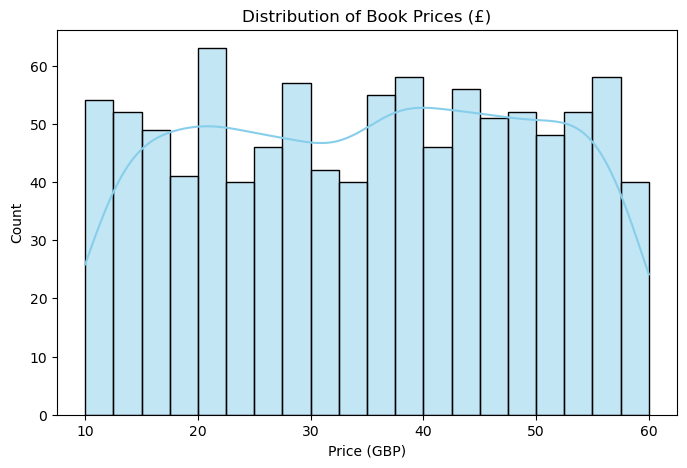

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["price_gbp"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Book Prices (£)")
plt.xlabel("Price (GBP)")
plt.savefig('price.png')
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_16752\3117261495.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=df, palette="magma")


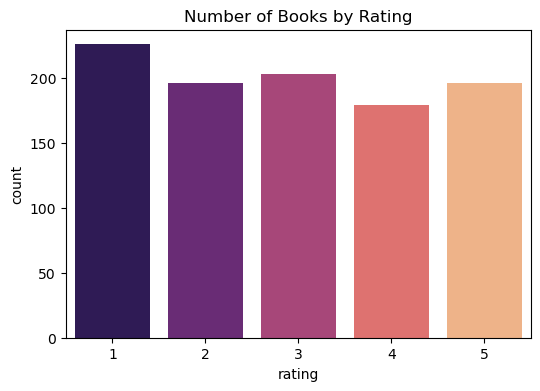

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(x="rating", data=df, palette="magma")
plt.title("Number of Books by Rating")
plt.savefig('rating2.png')
plt.show()

rating
1    34.561195
2    34.810918
3    34.692020
4    36.093296
5    35.374490
Name: price_gbp, dtype: float64


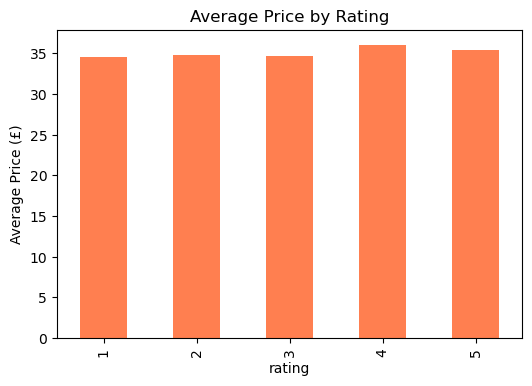

In [37]:
avg_price_by_rating = df.groupby("rating")["price_gbp"].mean()
print(avg_price_by_rating)

plt.figure(figsize=(6,4))
avg_price_by_rating.plot(kind="bar", color="coral")
plt.title("Average Price by Rating")
plt.ylabel("Average Price (£)")
plt.savefig('rating.png')
plt.show()

In [17]:
print(df["availability"].value_counts())


availability
In stock    1000
Name: count, dtype: int64


In [24]:
response = requests.get(url)
response.encoding = 'utf-8'   # ye line add karo
soup = BeautifulSoup(response.text, "html.parser")

In [26]:
base_url = "http://books.toscrape.com/catalogue/page-{}.html"
all_books = []
page = 1

while True:
    url = base_url.format(page)
    response = requests.get(url)
    response.encoding = 'utf-8'  # encoding fix
    
    if response.status_code != 200:
        break
    
    soup = BeautifulSoup(response.text, "html.parser")
    books = soup.find_all("article", class_="product_pod")
    
    if not books:
        break
    
    for book in books:
        title = book.h3.a["title"]
        
        price_text = book.find("p", class_="price_color").get_text(strip=True)
        price = float(price_text.replace("£", "").strip())  # $ ki jagah £
        
        availability = book.find("p", class_="instock availability").get_text(strip=True)
        
        rating_class = book.find("p", class_="star-rating")["class"][1]
        rating = rating_map.get(rating_class, None)
        
        relative_link = book.h3.a["href"]
        book_url = "http://books.toscrape.com/catalogue/" + relative_link.replace("../../../", "")
        
        all_books.append({
            "title": title,
            "price_gbp": price,
            "availability": availability,
            "rating": rating,
            "book_url": book_url
        })
    
    print(f"Page {page} scraped, total books so far: {len(all_books)}")
    page += 1
    time.sleep(1)

print("Scraping complete! Total books:", len(all_books))

Page 1 scraped, total books so far: 20
Page 2 scraped, total books so far: 40
Page 3 scraped, total books so far: 60
Page 4 scraped, total books so far: 80
Page 5 scraped, total books so far: 100
Page 6 scraped, total books so far: 120
Page 7 scraped, total books so far: 140
Page 8 scraped, total books so far: 160
Page 9 scraped, total books so far: 180
Page 10 scraped, total books so far: 200
Page 11 scraped, total books so far: 220
Page 12 scraped, total books so far: 240
Page 13 scraped, total books so far: 260
Page 14 scraped, total books so far: 280
Page 15 scraped, total books so far: 300
Page 16 scraped, total books so far: 320
Page 17 scraped, total books so far: 340
Page 18 scraped, total books so far: 360
Page 19 scraped, total books so far: 380
Page 20 scraped, total books so far: 400
Page 21 scraped, total books so far: 420
Page 22 scraped, total books so far: 440
Page 23 scraped, total books so far: 460
Page 24 scraped, total books so far: 480
Page 25 scraped, total books 

In [30]:
descriptions = []
upcs = []

for i, row in enumerate(all_books):
    try:
        response = requests.get(row["book_url"])
        soup = BeautifulSoup(response.text, "html.parser")
        
        # Description
        desc_tag = soup.find("div", id="product_description")
        if desc_tag:
            description = desc_tag.find_next_sibling("p").get_text(strip=True)
        else:
            description = "No description available"
        
        # UPC (product info table se)
        table = soup.find("table", class_="table table-striped")
        upc = table.find("th", string="UPC").find_next_sibling("td").get_text(strip=True)
        
        descriptions.append(description)
        upcs.append(upc)
        
    except Exception as e:
        descriptions.append(None)
        upcs.append(None)
        print(f"Error at book {i}: {e}")
    
    if i % 50 == 0:
        print(f"Processed {i}/{len(all_books)} books...")
    
    time.sleep(0.5)  # detail pages zyada hain, thoda slow rakhna better hai

print("Detail scraping complete!")

Processed 0/1000 books...
Processed 50/1000 books...
Processed 100/1000 books...
Processed 150/1000 books...
Processed 200/1000 books...
Processed 250/1000 books...
Processed 300/1000 books...
Processed 350/1000 books...
Processed 400/1000 books...
Processed 450/1000 books...
Processed 500/1000 books...
Processed 550/1000 books...
Processed 600/1000 books...
Processed 650/1000 books...
Processed 700/1000 books...
Processed 750/1000 books...
Processed 800/1000 books...
Processed 850/1000 books...
Processed 900/1000 books...
Processed 950/1000 books...
Detail scraping complete!


In [31]:
df = pd.DataFrame(all_books)
df["description"] = descriptions
df["upc"] = upcs

df.head()

,title,price_gbp,availability,rating,book_url,description,upc
0,A Light in the Attic,51.77,In stock,3,http://books.toscrape.com/catalogue/a-light-in...,It's hard to imagine a world without A Light i...,a897fe39b1053632
1,Tipping the Velvet,53.74,In stock,1,http://books.toscrape.com/catalogue/tipping-th...,"""Erotic and absorbing...Written with starling ...",90fa61229261140a
2,Soumission,50.10,In stock,1,http://books.toscrape.com/catalogue/soumission...,"Dans une France assez proche de la nÃ´tre, un ...",6957f44c3847a760
3,Sharp Objects,47.82,In stock,4,http://books.toscrape.com/catalogue/sharp-obje...,"WICKED above her hipbone, GIRL across her hear...",e00eb4fd7b871a48
4,Sapiens: A Brief History of Humankind,54.23,In stock,5,http://books.toscrape.com/catalogue/sapiens-a-...,From a renowned historian comes a groundbreaki...,4165285e1663650f


In [32]:
df.to_csv("books_dataset_full.csv", index=False)
print(df.shape)

(1000, 7)


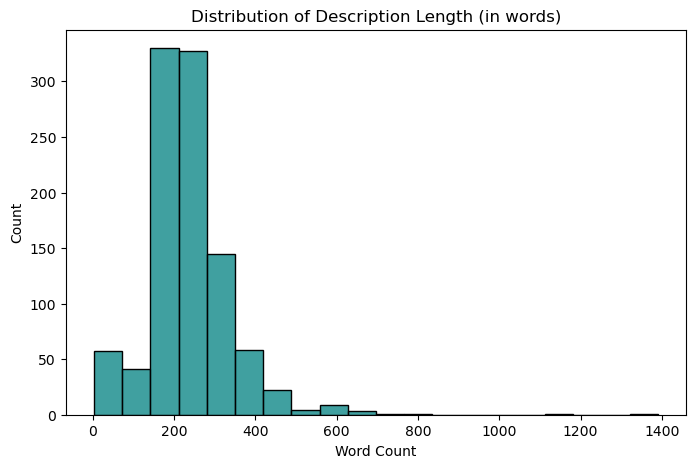

In [38]:
df["desc_length"] = df["description"].apply(lambda x: len(x.split()) if x else 0)

plt.figure(figsize=(8,5))
sns.histplot(df["desc_length"], bins=20, color="teal")
plt.title("Distribution of Description Length (in words)")
plt.xlabel("Word Count")
plt.savefig('word_count.png')
plt.show()

In [34]:
# Sirf pehle 10 books pe test karo
test_books = all_books[:10]
for row in test_books:
    print(row["title"], "->", row["book_url"])

A Light in the Attic -> http://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html
Tipping the Velvet -> http://books.toscrape.com/catalogue/tipping-the-velvet_999/index.html
Soumission -> http://books.toscrape.com/catalogue/soumission_998/index.html
Sharp Objects -> http://books.toscrape.com/catalogue/sharp-objects_997/index.html
Sapiens: A Brief History of Humankind -> http://books.toscrape.com/catalogue/sapiens-a-brief-history-of-humankind_996/index.html
The Requiem Red -> http://books.toscrape.com/catalogue/the-requiem-red_995/index.html
The Dirty Little Secrets of Getting Your Dream Job -> http://books.toscrape.com/catalogue/the-dirty-little-secrets-of-getting-your-dream-job_994/index.html
The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull -> http://books.toscrape.com/catalogue/the-coming-woman-a-novel-based-on-the-life-of-the-infamous-feminist-victoria-woodhull_993/index.html
The Boys in the Boat: Nine Americans and Their Epic Qu